In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE = Path.cwd().parent
RAW  = BASE / "data" / "raw"
PROCESSED = (Path.cwd().parent/"data"/"processed")
CHARTS = BASE / "reports" / "charts"

CHARTS.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid")

In [3]:
#loading files
funds = pd.read_csv(PROCESSED / "clean_fund_master.csv")
nav = pd.read_csv(PROCESSED / "clean_nav.csv")
aum = pd.read_csv(PROCESSED / "clean_aum.csv")
sip = pd.read_csv(PROCESSED / "clean_sip_inflows.csv")
category = pd.read_csv(PROCESSED / "clean_category_inflows.csv")
folios = pd.read_csv(PROCESSED / "clean_folio_count.csv")
transactions = pd.read_csv(PROCESSED / "clean_transactions.csv")
holdings = pd.read_csv(PROCESSED / "clean_portfolio.csv")
benchmarks = pd.read_csv(PROCESSED / "clean_benchmark.csv")

nav["date"] = pd.to_datetime(nav["date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
sip["month"] = pd.to_datetime(sip["month"])

In [4]:
datasets = {
    "funds": funds,
    "nav": nav,
    "aum": aum,
    "sip": sip,
    "category": category,
    "folios": folios,
    "transactions": transactions,
    "holdings": holdings,
    "benchmarks": benchmarks
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.shape)
    display(df.head())
    print(df.isna().sum().sort_values(ascending=False).head())


FUNDS
(40, 15)


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


amfi_code       0
fund_house      0
scheme_name     0
category        0
sub_category    0
dtype: int64

NAV
(46000, 4)


,date,amfi_code,nav,daily_return_pct
0,2022-01-03,100016,520.4608,NaN
1,2022-01-04,100016,515.0971,-1.030568
2,2022-01-05,100016,521.7239,1.286515
3,2022-01-06,100016,515.7880,-1.137747
4,2022-01-07,100016,515.1639,-0.120999


daily_return_pct    40
date                 0
amfi_code            0
nav                  0
dtype: int64

AUM
(90, 5)


...

investor_id         0
transaction_date    0
amfi_code           0
transaction_type    0
amount_inr          0
dtype: int64

HOLDINGS
(322, 8)


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


amfi_code       0
stock_symbol    0
stock_name      0
sector          0
weight_pct      0
dtype: int64

BENCHMARKS
(8050, 3)


,date,index_name,close_value
0,2022-01-03,BSE_SMALLCAP,26554.60
1,2022-01-04,BSE_SMALLCAP,27079.92
2,2022-01-05,BSE_SMALLCAP,27313.35
3,2022-01-06,BSE_SMALLCAP,27377.05
4,2022-01-07,BSE_SMALLCAP,26316.86


date           0
index_name     0
close_value    0
dtype: int64


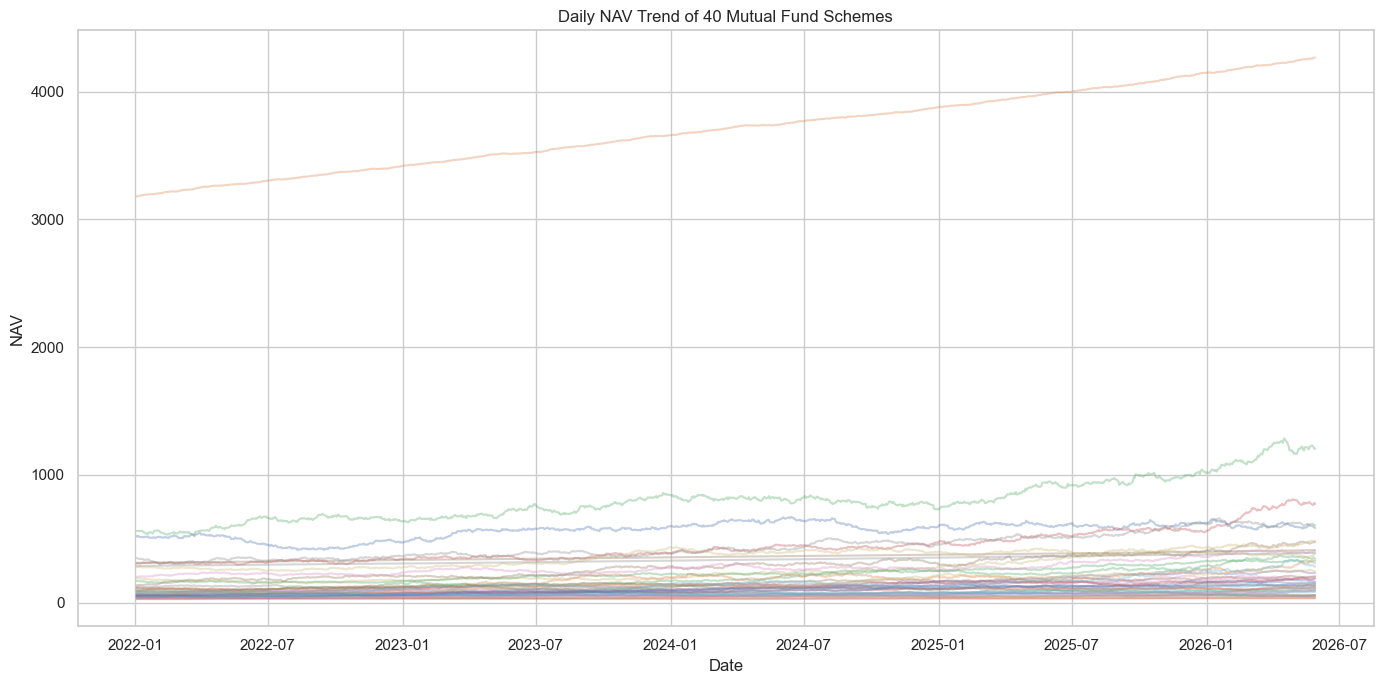

In [7]:
#Nav trends 
nav_merged = nav.merge(
    funds[["amfi_code", "scheme_name", "fund_house", "category"]],
    on="amfi_code",
    how="left"
)

plt.figure(figsize=(14, 7))

for code, group in nav_merged.groupby("amfi_code"):
    plt.plot(group["date"], group["nav"], alpha=0.35)

plt.title("Daily NAV Trend of 40 Mutual Fund Schemes")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.tight_layout()
plt.savefig(CHARTS / "01_nav_trend_all_schemes.png", dpi=300)
plt.show()

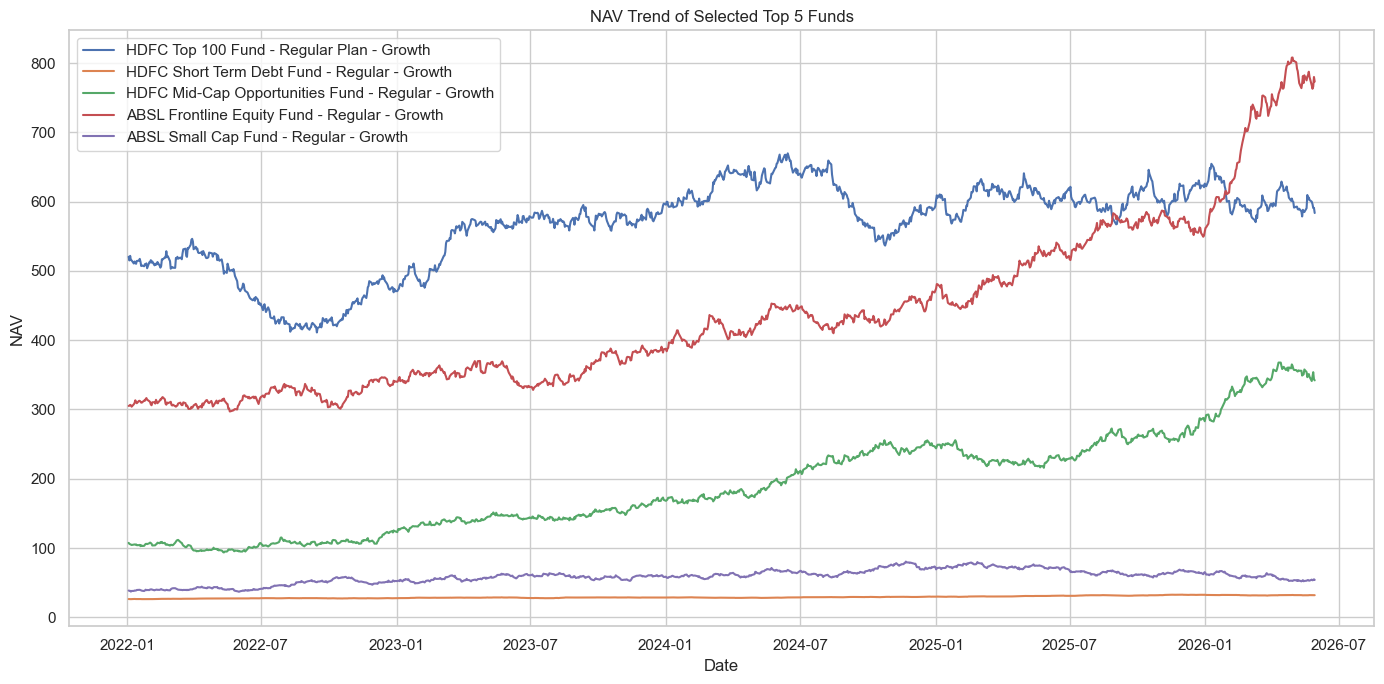

In [8]:
#nav trends for top 5 firms

top_codes = nav_merged["amfi_code"].drop_duplicates().head(5)

plt.figure(figsize=(14, 7))

for code in top_codes:
    temp = nav_merged[nav_merged["amfi_code"] == code]
    label = temp["scheme_name"].iloc[0]
    plt.plot(temp["date"], temp["nav"], label=label)

plt.title("NAV Trend of Selected Top 5 Funds")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.tight_layout()
plt.savefig(CHARTS / "02_nav_trend_top5.png", dpi=300)
plt.show()

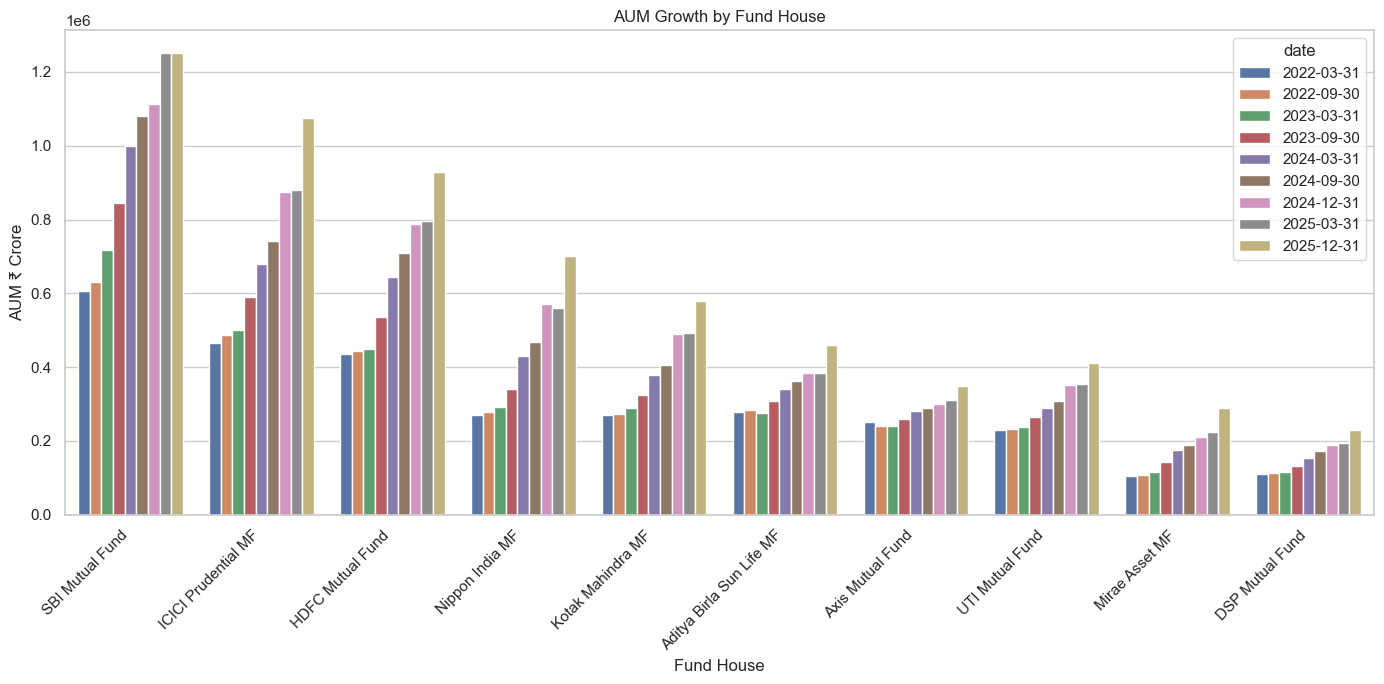

In [9]:
#aum by fund house
aum.columns

plt.figure(figsize=(14, 7))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_crore",
    hue="date"
)

plt.title("AUM Growth by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM ₹ Crore")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(CHARTS / "03_aum_growth_by_amc.png", dpi=300)
plt.show()

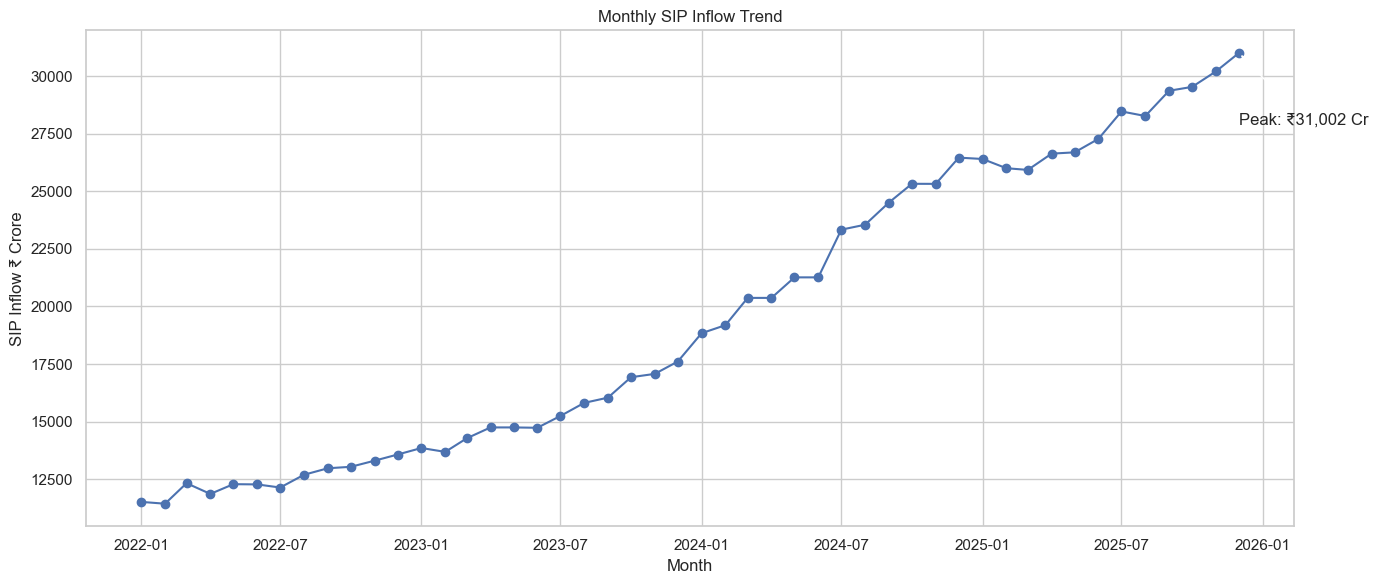

In [10]:
#sip inflow trend

plt.figure(figsize=(14, 6))

plt.plot(sip["month"], sip["sip_inflow_crore"], marker="o")
plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow ₹ Crore")

max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]
plt.annotate(
    f"Peak: ₹{max_row['sip_inflow_crore']:,.0f} Cr",
    xy=(max_row["month"], max_row["sip_inflow_crore"]),
    xytext=(max_row["month"], max_row["sip_inflow_crore"] * 0.9),
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()
plt.savefig(CHARTS / "04_sip_inflow_trend.png", dpi=300)
plt.show()

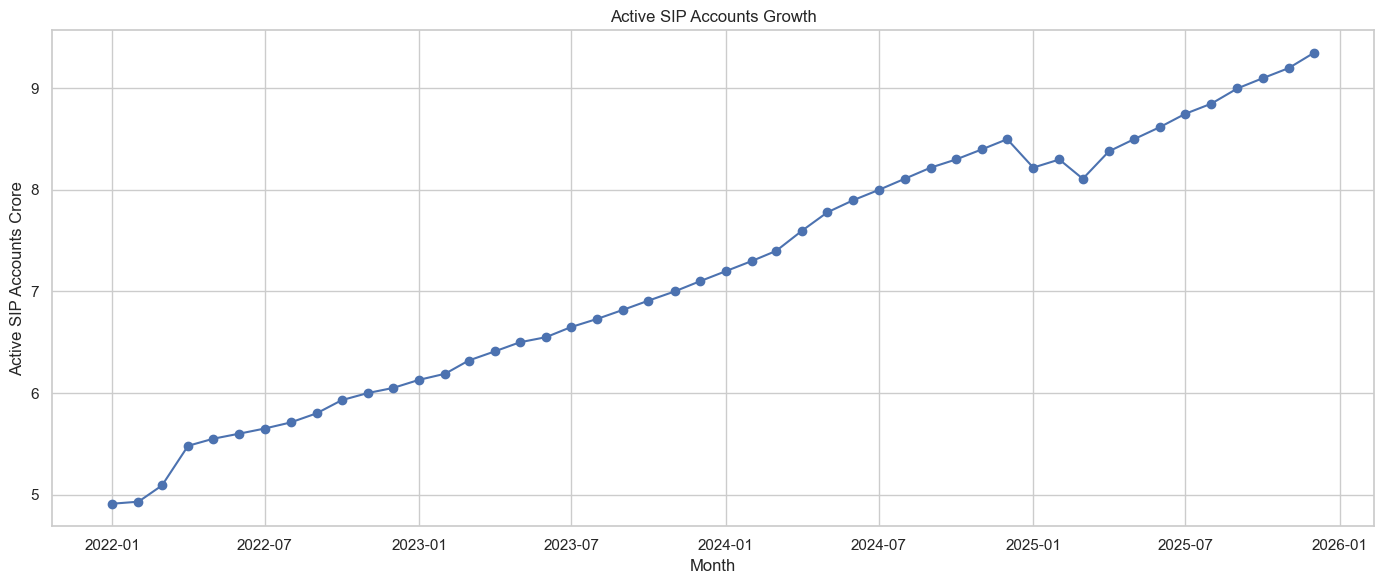

In [11]:
#sip acc growth
plt.figure(figsize=(14, 6))

plt.plot(sip["month"], sip["active_sip_accounts_crore"], marker="o")

plt.title("Active SIP Accounts Growth")
plt.xlabel("Month")
plt.ylabel("Active SIP Accounts Crore")
plt.tight_layout()
plt.savefig(CHARTS / "05_sip_accounts_growth.png", dpi=300)
plt.show()

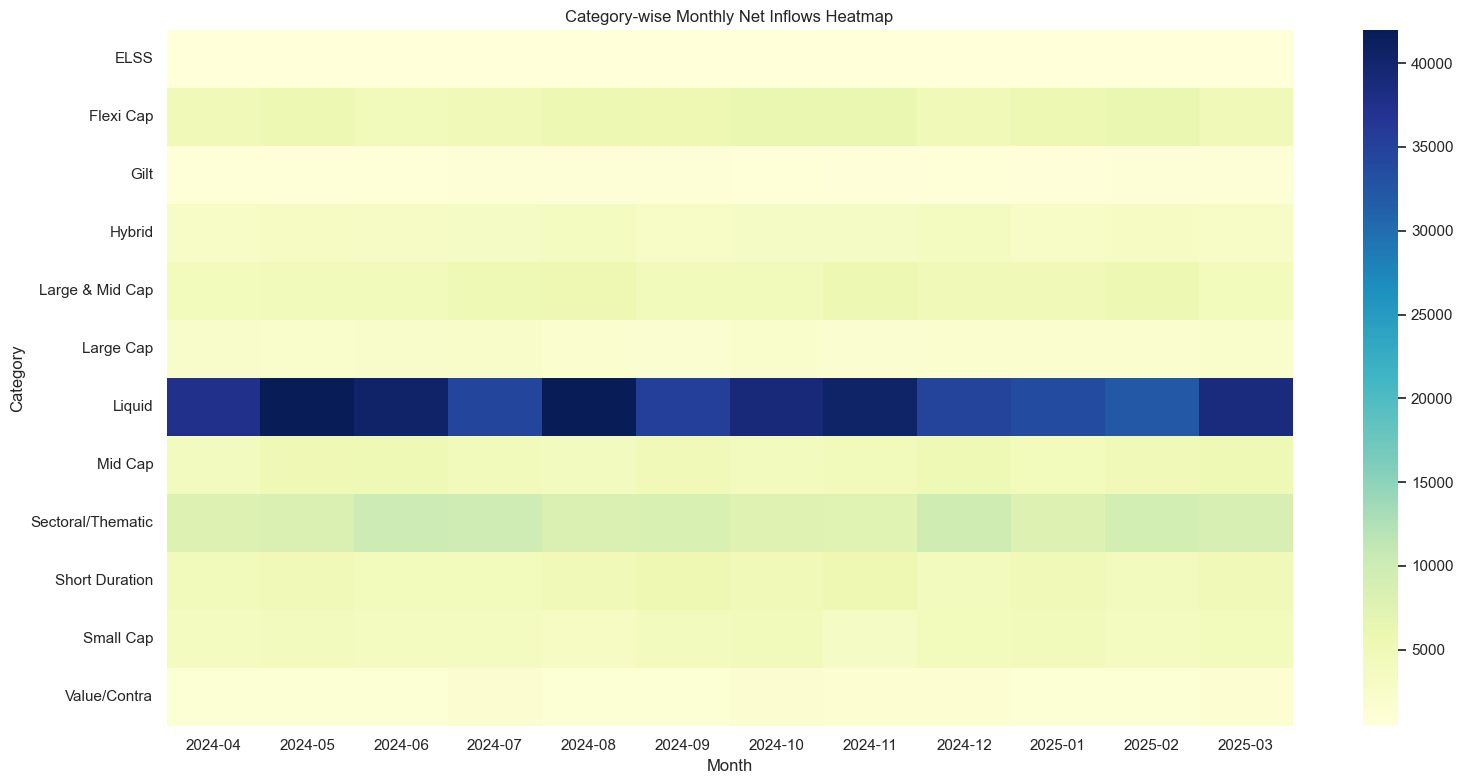

In [13]:
#categpry inflow heatmap

category.columns
category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot_table(
    index="category",
    columns=category["month"].dt.strftime("%Y-%m"),
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_data, cmap="YlGnBu")

plt.title("Category-wise Monthly Net Inflows Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(CHARTS / "06_category_inflow_heatmap.png", dpi=300)
plt.show()


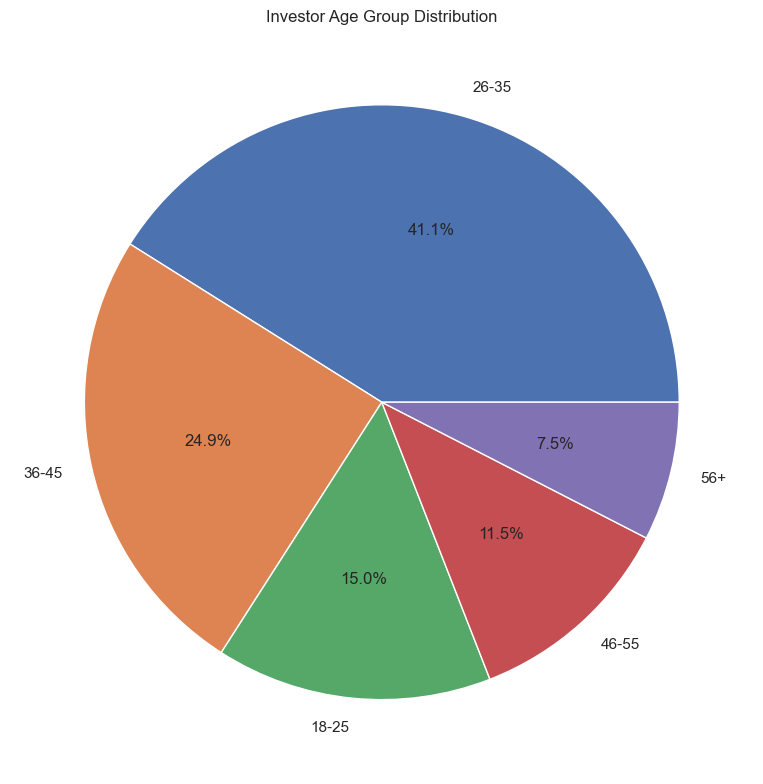

In [14]:
#age grp distribution

age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(age_counts, labels=age_counts.index, autopct="%1.1f%%")
plt.title("Investor Age Group Distribution")
plt.tight_layout()
plt.savefig(CHARTS / "07_age_group_distribution.png", dpi=300)
plt.show()

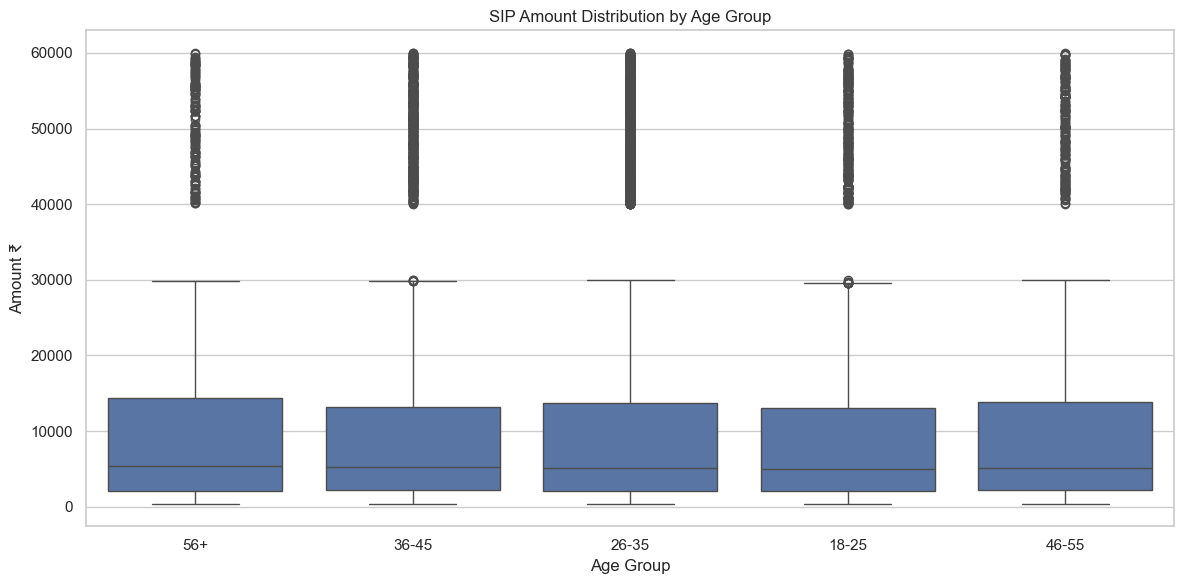

In [15]:
#sip amount by age grp
sip_tx = transactions[transactions["transaction_type"].str.upper() == "SIP"]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=sip_tx,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount ₹")
plt.tight_layout()
plt.savefig(CHARTS / "08_sip_amount_by_age_group.png", dpi=300)
plt.show()

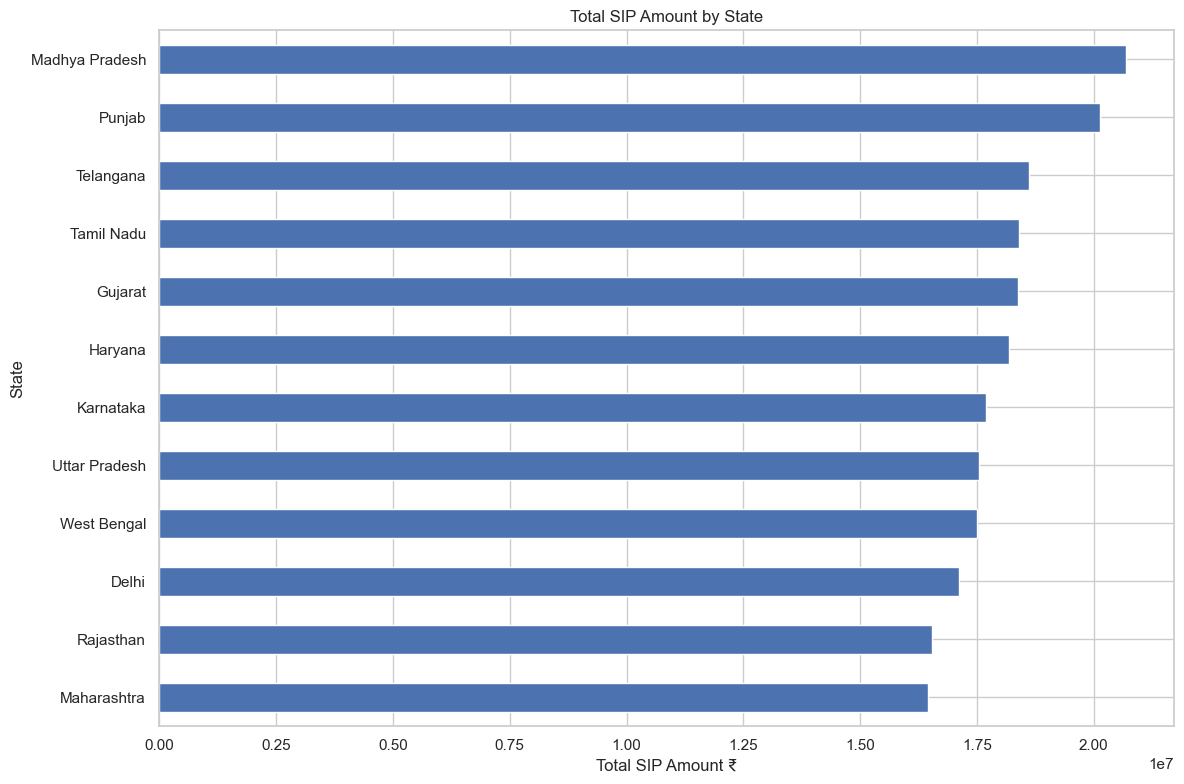

In [16]:
#sip amount by state
state_sip = sip_tx.groupby("state")["amount_inr"].sum().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
state_sip.plot(kind="barh")

plt.title("Total SIP Amount by State")
plt.xlabel("Total SIP Amount ₹")
plt.ylabel("State")
plt.tight_layout()
plt.savefig(CHARTS / "09_sip_amount_by_state.png", dpi=300)
plt.show()

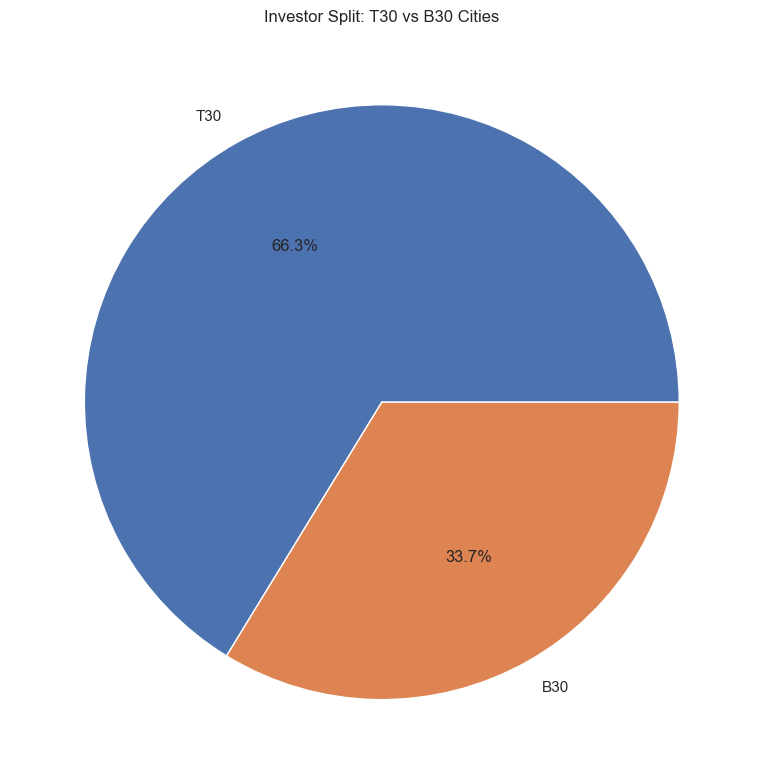

In [17]:
#t30vs b30 split

tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(tier_counts, labels=tier_counts.index, autopct="%1.1f%%")
plt.title("Investor Split: T30 vs B30 Cities")
plt.tight_layout()
plt.savefig(CHARTS / "10_t30_b30_split.png", dpi=300)
plt.show()

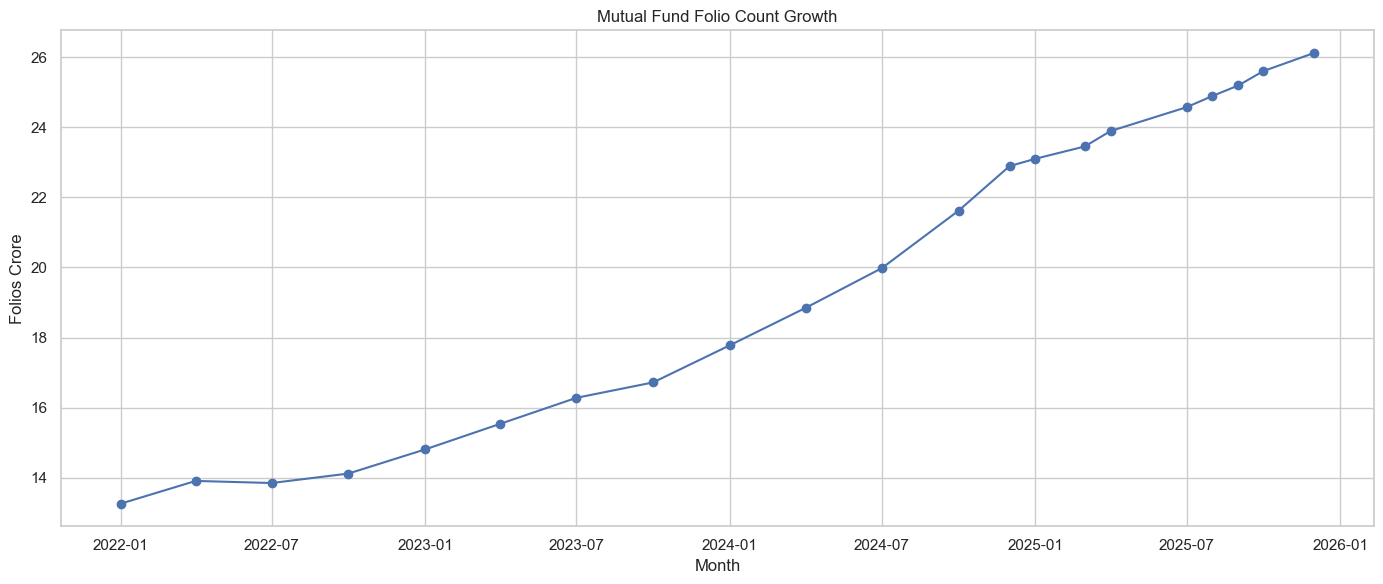

In [19]:
#folio count growth

folios.columns
folios["month"] = pd.to_datetime(folios["month"])

plt.figure(figsize=(14, 6))
plt.plot(folios["month"], folios["total_folios_crore"], marker="o")

plt.title("Mutual Fund Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Folios Crore")
plt.tight_layout()
plt.savefig(CHARTS / "11_folio_count_growth.png", dpi=300)
plt.show()

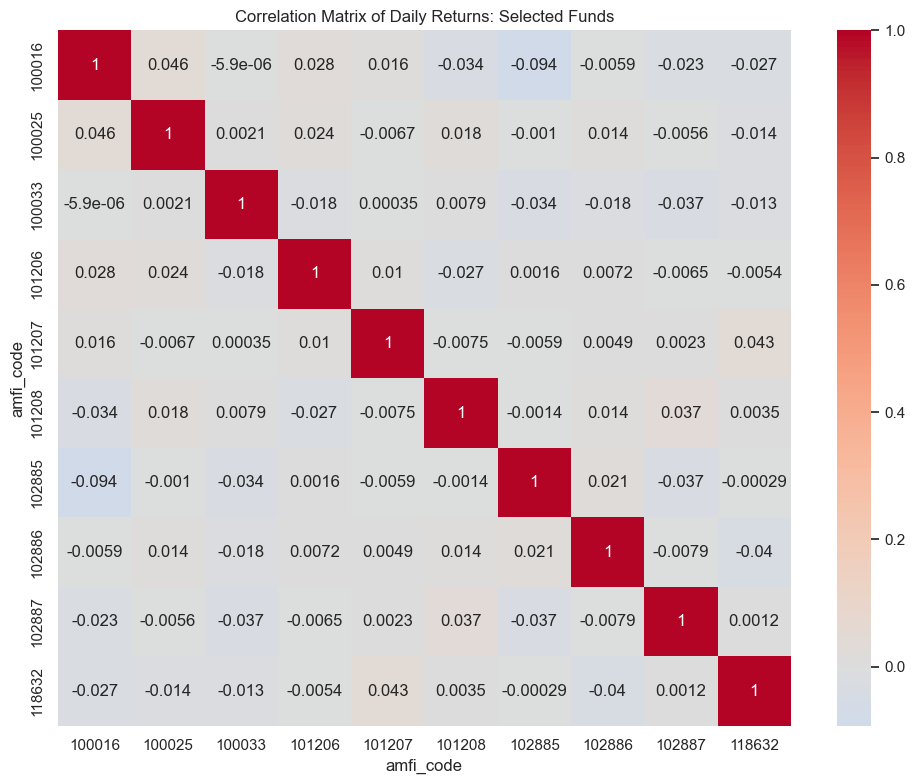

In [20]:
#Corr matrix of selected fund returns

nav_returns = nav_merged.sort_values(["amfi_code", "date"])
nav_returns["daily_return"] = nav_returns.groupby("amfi_code")["nav"].pct_change()

selected_codes = nav_returns["amfi_code"].drop_duplicates().head(10)

return_pivot = nav_returns[nav_returns["amfi_code"].isin(selected_codes)].pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

corr = return_pivot.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)

plt.title("Correlation Matrix of Daily Returns: Selected Funds")
plt.tight_layout()
plt.savefig(CHARTS / "12_return_correlation_matrix.png", dpi=300)
plt.show()

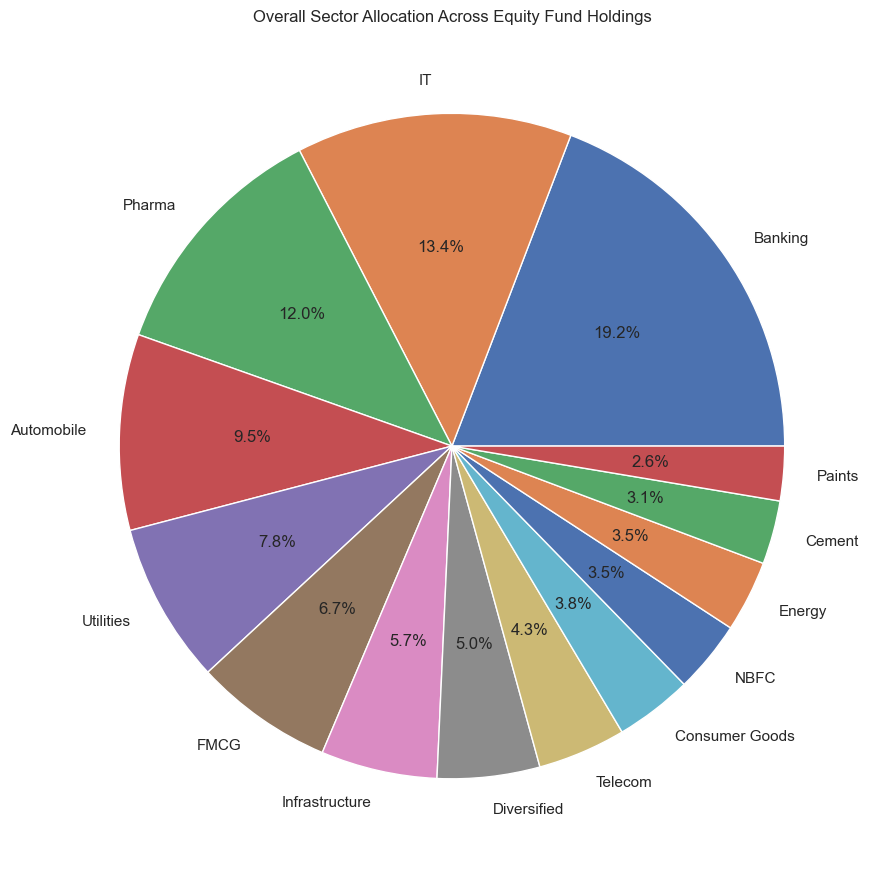

In [21]:
#sector allocation
sector_weights = holdings.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 9))
plt.pie(sector_weights, labels=sector_weights.index, autopct="%1.1f%%")
plt.title("Overall Sector Allocation Across Equity Fund Holdings")
plt.tight_layout()
plt.savefig(CHARTS / "13_sector_allocation.png", dpi=300)
plt.show()

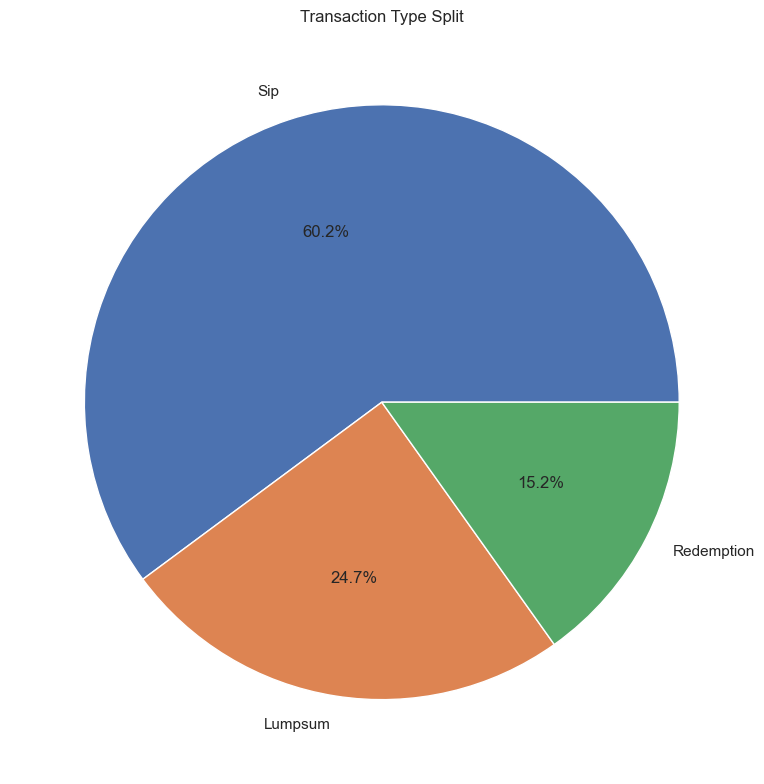

In [22]:
#transaction via type split
tx_split = transactions["transaction_type"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(tx_split, labels=tx_split.index, autopct="%1.1f%%")
plt.title("Transaction Type Split")
plt.tight_layout()
plt.savefig(CHARTS / "14_transaction_type_split.png", dpi=300)
plt.show()

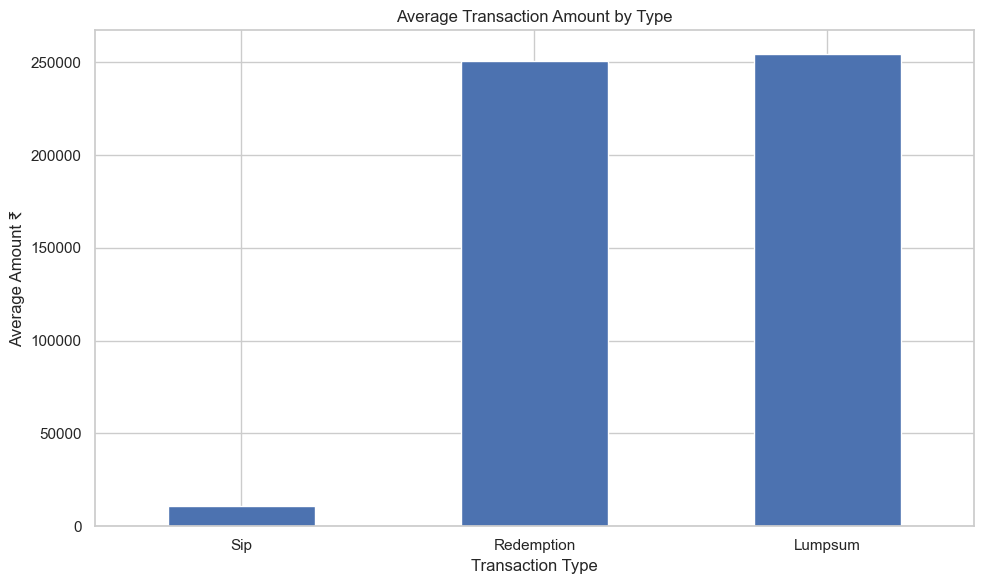

In [23]:
#avg transaction amount by transation type

avg_tx = transactions.groupby("transaction_type")["amount_inr"].mean().sort_values()

plt.figure(figsize=(10, 6))
avg_tx.plot(kind="bar")

plt.title("Average Transaction Amount by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Average Amount ₹")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(CHARTS / "15_avg_transaction_amount_by_type.png", dpi=300)
plt.show()

In [24]:
#eda summary

summary = {
    "total_funds": funds["amfi_code"].nunique(),
    "nav_start_date": nav["date"].min(),
    "nav_end_date": nav["date"].max(),
    "total_transactions": len(transactions),
    "total_sip_amount": sip_tx["amount_inr"].sum(),
    "top_state_by_sip": state_sip.idxmax(),
    "top_state_sip_amount": state_sip.max()
}

eda_summary = pd.DataFrame([summary])
eda_summary.to_csv(PROCESSED / "eda_summary.csv", index=False)

eda_summary

,total_funds,nav_start_date,nav_end_date,total_transactions,total_sip_amount,top_state_by_sip,top_state_sip_amount
0,40,2022-01-03,2026-05-29,32778,217233491,Madhya Pradesh,20682243
